# DECA Model Training Notebook — results on the Tier‑6 lake

**Default mode = see results** (does **not** wipe or overwrite the promoted School Exam classifier).

| Stage | What you see |
| --- | --- |
| 0 | New lake audit (23,909 rows after campaign `20260714_165648_tier6_x10`) |
| 0b | Fault behaviour gallery |
| 1–4 | Score the **live** models under `models/` (IF, promoted XGB, Prophet, LSTM) |
| 5 | Topology |
| 6 | Classroom (School Exam) + playground scoreboards + charts |

Promotion / retrain belongs to the scripts (not this notebook by default):

```bash
python scripts/deca_mlops_orchestrator.py --mode B --rpi-run <id>
python scripts/deca_retrain_companions.py
python scripts/deca_school_exam_train.py --report-seeds 5
python scripts/deca_model_playground.py --exam-seed 20260715
```

Scores doc: [`docs/DECA_TEST_SCORES.md`](../docs/DECA_TEST_SCORES.md).

Set `REBUILD_MODELS = True` below only if you intentionally want a full from-scratch notebook retrain (will overwrite companions; still skips promoting a new classifier unless you also flip `OVERWRITE_CLASSIFIER`).


In [1]:
from __future__ import annotations

import json
import sys
import warnings
from datetime import datetime, timezone
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
from sklearn.metrics import (
    RocCurveDisplay,
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    recall_score,
    roc_auc_score,
)

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)
try:
    plt.style.use("seaborn-v0_8-whitegrid")
except OSError:
    plt.style.use("ggplot")
%matplotlib inline

REPO_ROOT = Path.cwd()
if not ((REPO_ROOT / "data").is_dir() and (REPO_ROOT / "models").is_dir()):
    if (REPO_ROOT.parent / "data").is_dir():
        REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "scripts"))

from _paths import MODELS_DIR, PROCESSED_DIR, RPI_NET_DIR  # noqa: E402
from rebuild_unified import UNIFIED_LABELS, to_unified_label  # noqa: E402
from deca_school_exam_train import (  # noqa: E402
    RARE,
    feature_columns,
    predict_weighted_multiclass,
    stratified_blind_holdout,
)

# --- safety switches ---------------------------------------------------------
REBUILD_MODELS = False          # True = call companion retrain script (slow)
OVERWRITE_CLASSIFIER = False    # keep False — School Exam / orchestrator owns promote
EXAM_SEED = 20260715            # same paper as docs playground snapshot
RANDOM_STATE = 42
SEQ_LEN = 16

META_COLS = {
    "run_id", "source", "fault_type", "unified_label",
    "is_anomaly", "time_to_breach_minutes", "timestamp",
}

print(f"REPO_ROOT = {REPO_ROOT}")
print(f"PROCESSED = {PROCESSED_DIR}")
print(f"MODELS   = {MODELS_DIR}")
print(f"REBUILD_MODELS={REBUILD_MODELS}  OVERWRITE_CLASSIFIER={OVERWRITE_CLASSIFIER}")
assert not OVERWRITE_CLASSIFIER, "Refusing to overwrite champion — use School Exam scripts to promote."


REPO_ROOT = /home/brain/deca-isro
PROCESSED = /home/brain/deca-isro/data/processed
MODELS   = /home/brain/deca-isro/models
REBUILD_MODELS=False  OVERWRITE_CLASSIFIER=False


## Stage 0 — Load unified lake & label audit (Tier‑6)


rows=23,909  features=20  sources={'network': 15631, 'public': 8278}


,count
unified_label,
healthy,19961
congestion_breach,1260
bgp_route_flap,1224
tunnel_degradation,849
vrf_leakage,615


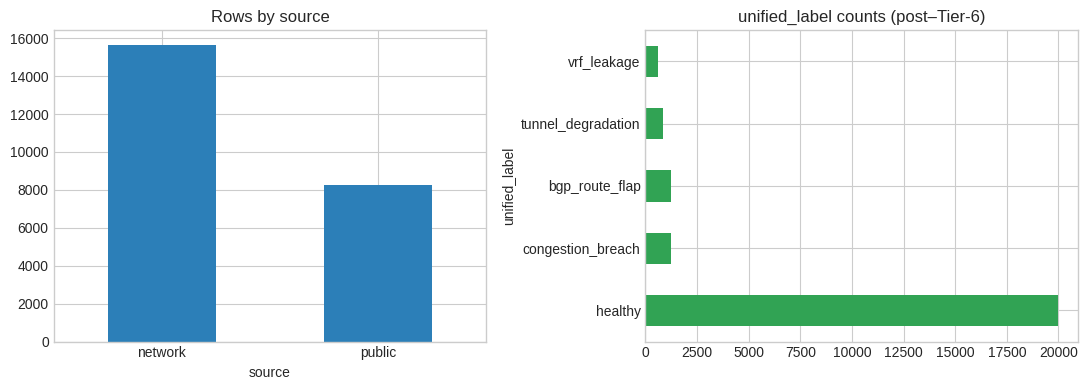

**After Tier‑6 ingest:** `23,909` rows · BGP=1,224 · VRF=615

In [2]:
path = PROCESSED_DIR / "deca_unified_dataset.parquet"
df = pd.read_parquet(path)
if "unified_label" not in df.columns:
    df["unified_label"] = df["fault_type"].map(to_unified_label)
if "is_anomaly" not in df.columns:
    df["is_anomaly"] = (df["unified_label"] != "healthy").astype(int)
if not isinstance(df.index, pd.DatetimeIndex):
    if "timestamp" in df.columns:
        df = df.set_index(pd.to_datetime(df["timestamp"], utc=True))
    else:
        df.index = pd.to_datetime(df.index, utc=True)
df = df.sort_index()
feats = feature_columns(df)

print(f"rows={len(df):,}  features={len(feats)}  sources={df['source'].value_counts().to_dict()}")
display(df["unified_label"].value_counts().to_frame("count"))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
df["source"].value_counts().plot(kind="bar", ax=axes[0], color="#2c7fb8", title="Rows by source")
df["unified_label"].value_counts().plot(kind="barh", ax=axes[1], color="#31a354", title="unified_label counts (post–Tier-6)")
axes[0].tick_params(axis="x", rotation=0)
fig.tight_layout()
plt.show()

display(Markdown(
    f"**After Tier‑6 ingest:** `{len(df):,}` rows · "
    f"BGP={int((df.unified_label=='bgp_route_flap').sum()):,} · "
    f"VRF={int((df.unified_label=='vrf_leakage').sum()):,}"
))


## Stage 0b — Fault behaviour gallery (visual signatures)

Plot how each lab fault type looks in telemetry. Prefers the completed Tier‑6 export.


Using campaign: 20260714_165648_tier6_x10
hosts: ['station1', 'station2', 'station3']
faults by type:
 fault_type
vrf_leakage           10
congestion_breach     10
tunnel_degradation    10
bgp_route_flap        10
plot host: station1


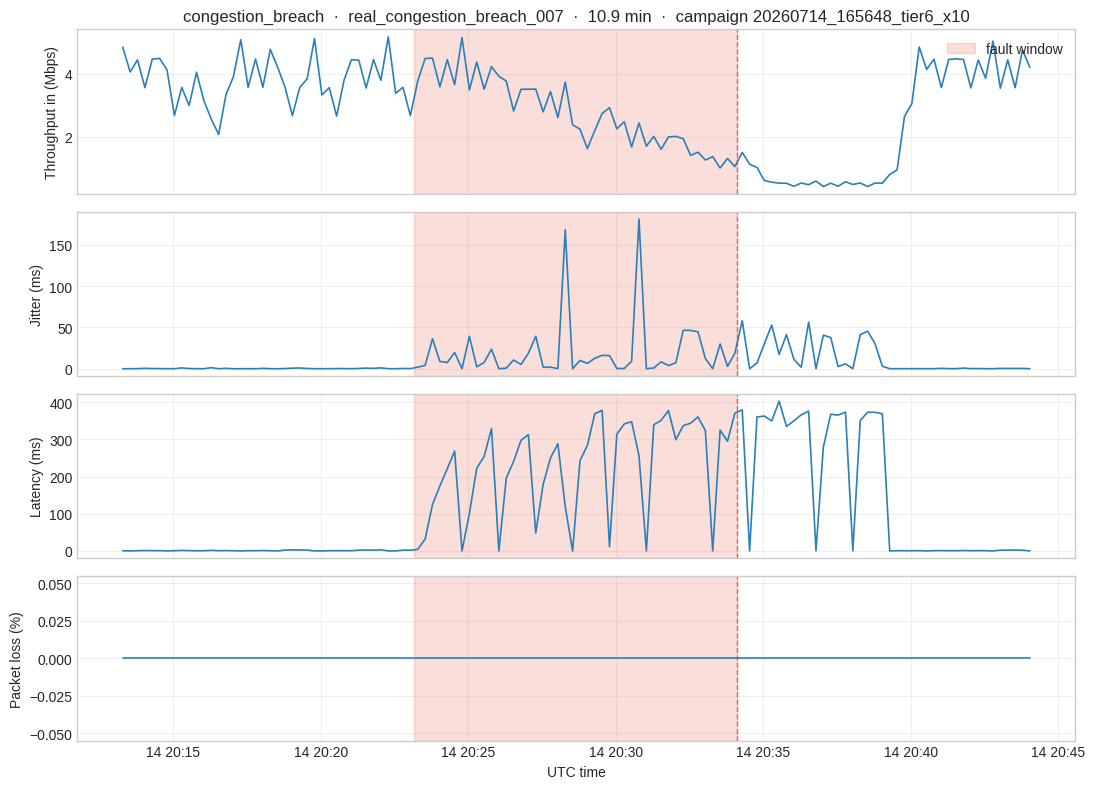

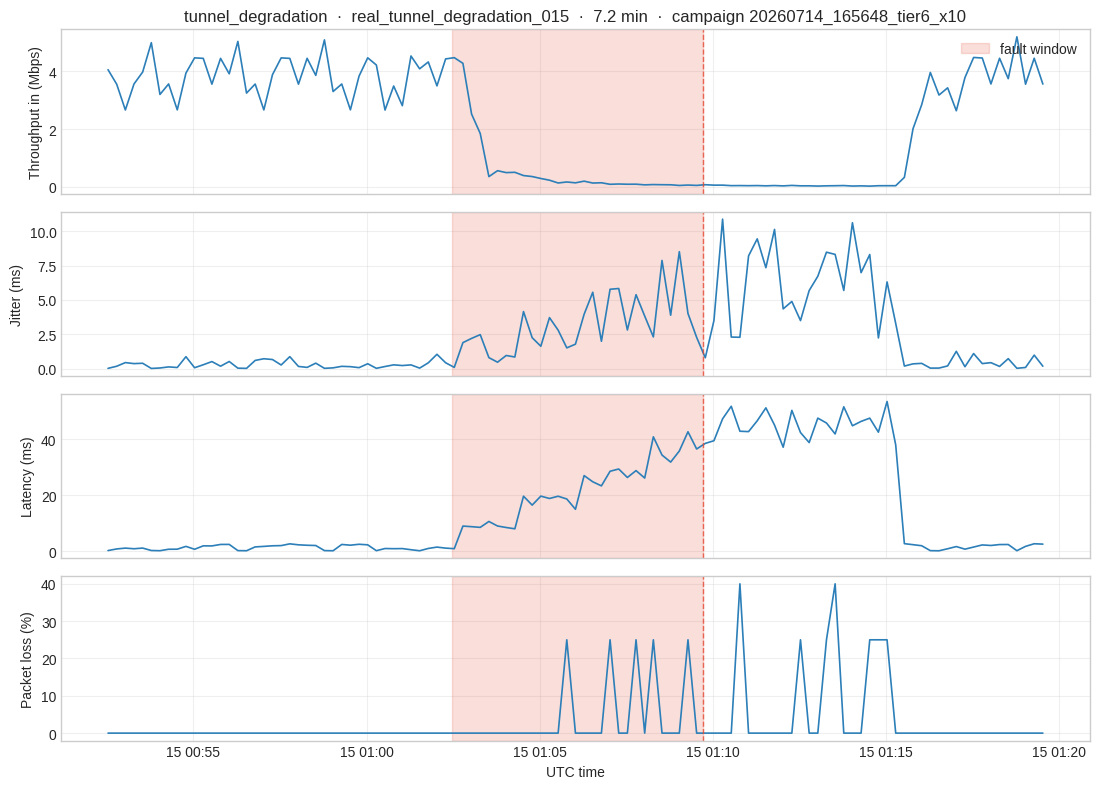

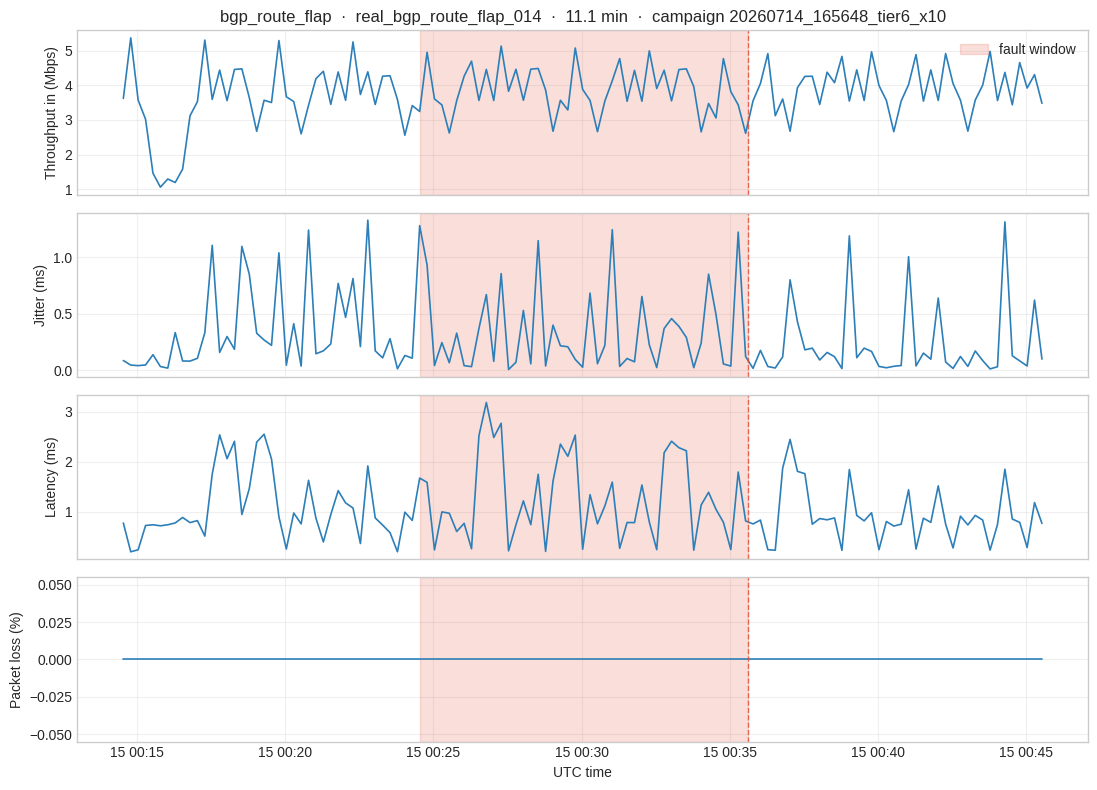

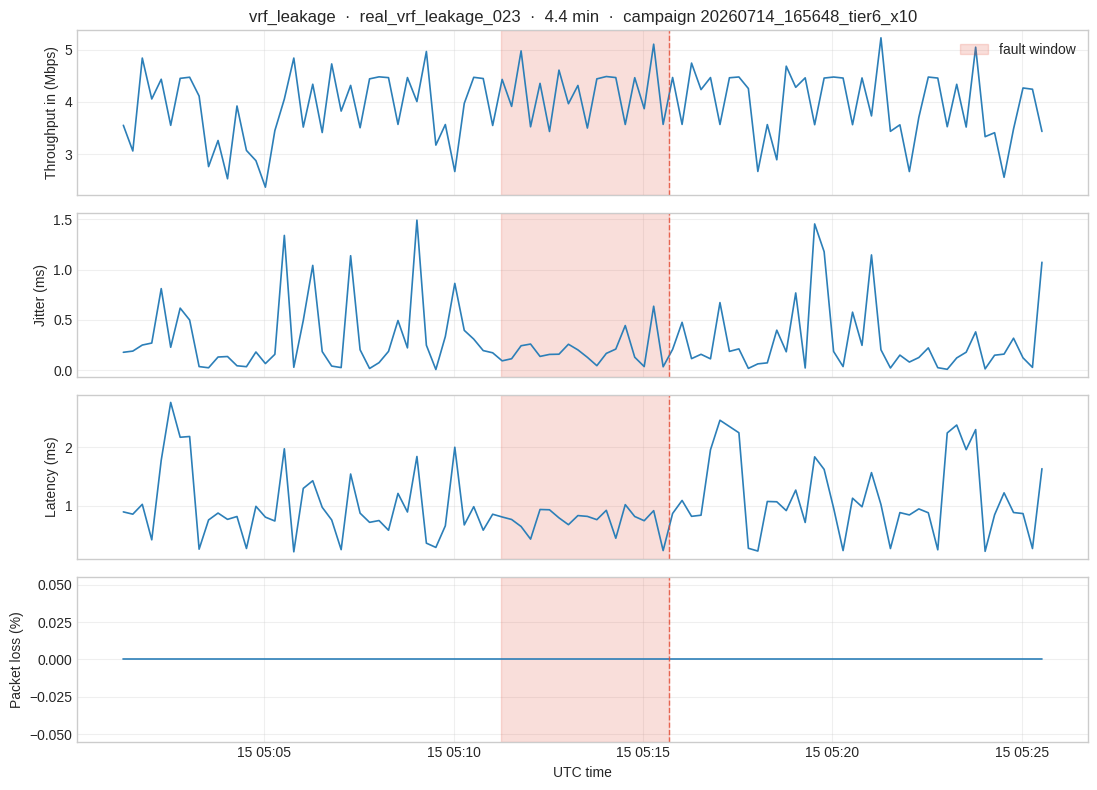

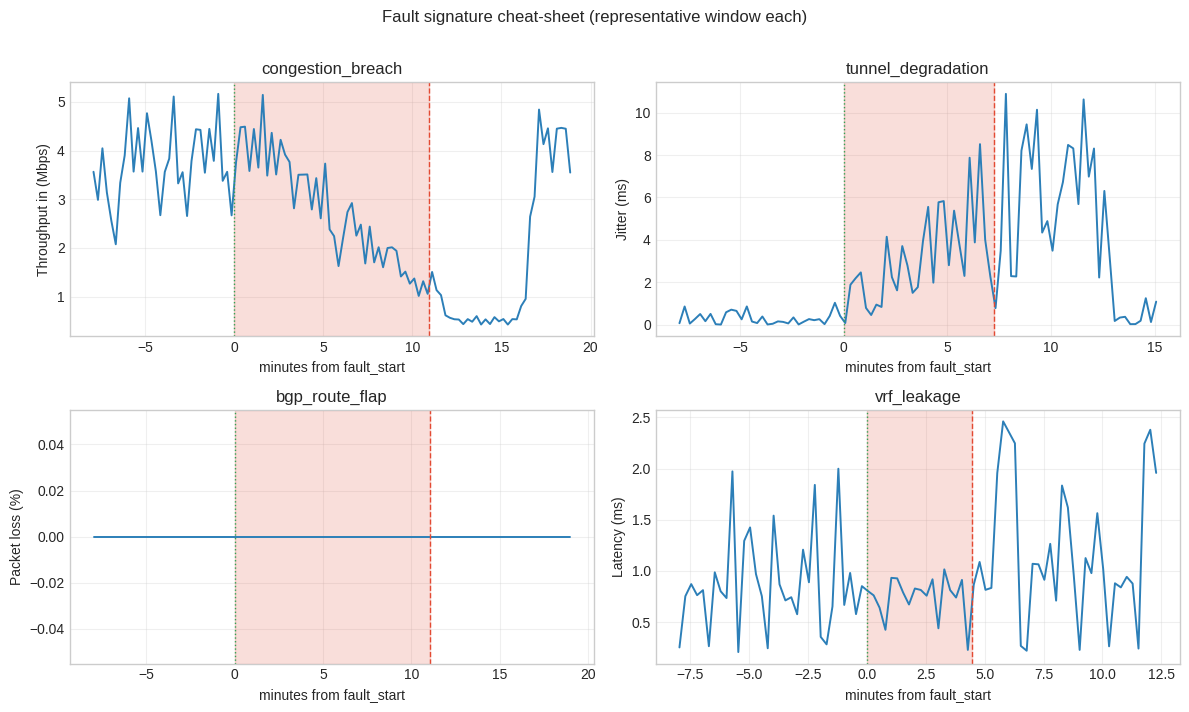

Re-run this cell to refresh live plots. Static copies (if previously exported) live under: /home/brain/deca-isro/notebook/figures/fault_behaviour


,fault_type,run_id,fault_start,breach_time,duration_min
0,bgp_route_flap,real_bgp_route_flap_004,2026-07-14 18:58:57.710353+00:00,2026-07-14 19:09:51.103531+00:00,10.889886
1,bgp_route_flap,real_bgp_route_flap_005,2026-07-14 19:28:32.516236+00:00,2026-07-14 19:35:49.570631+00:00,7.284240
2,bgp_route_flap,real_bgp_route_flap_010,2026-07-14 22:11:50.619597+00:00,2026-07-14 22:22:37.423113+00:00,10.780059
3,bgp_route_flap,real_bgp_route_flap_014,2026-07-15 00:24:31.797868+00:00,2026-07-15 00:35:36.904736+00:00,11.085114
4,bgp_route_flap,real_bgp_route_flap_019,2026-07-15 03:11:44.298697+00:00,2026-07-15 03:23:13.547070+00:00,11.487473
5,bgp_route_flap,real_bgp_route_flap_022,2026-07-15 04:44:34.030487+00:00,2026-07-15 04:53:06.496612+00:00,8.541102
6,bgp_route_flap,real_bgp_route_flap_026,2026-07-15 06:57:35.413313+00:00,2026-07-15 07:09:35.452774+00:00,12.000658
7,bgp_route_flap,real_bgp_route_flap_030,2026-07-15 09:05:19.813423+00:00,2026-07-15 09:12:10.863807+00:00,6.850840
8,bgp_route_flap,real_bgp_route_flap_035,2026-07-15 11:41:35.907218+00:00,2026-07-15 11:53:01.155677+00:00,11.420808
9,bgp_route_flap,real_bgp_route_flap_037,2026-07-15 12:46:31.483392+00:00,2026-07-15 12:58:28.109078+00:00,11.943761


In [3]:
from pathlib import Path as _Path

# Prefer completed labeled export; fall back to newest run that has it
_runs = REPO_ROOT / "data" / "rpi-net" / "runs"
_candidates = sorted(
    [p for p in _runs.glob("*/network_campaign_export.csv") if p.is_file()],
    key=lambda p: p.stat().st_mtime,
    reverse=True,
)
if not _candidates:
    raise FileNotFoundError(
        "No network_campaign_export.csv under data/rpi-net/runs/ — "
        "finish a campaign (or use 20260713_155333) before plotting fault behaviour."
    )

CAMPAIGN_EXPORT = _candidates[0]
CAMPAIGN_DIR = CAMPAIGN_EXPORT.parent
FAULT_LOG = CAMPAIGN_DIR / "fault_injection_log.csv"
print("Using campaign:", CAMPAIGN_DIR.name)

telem = pd.read_csv(CAMPAIGN_EXPORT)
telem["timestamp"] = pd.to_datetime(telem["timestamp"], utc=True)
flog = pd.read_csv(FAULT_LOG)
flog["fault_start"] = pd.to_datetime(flog["fault_start"], utc=True)
flog["breach_time"] = pd.to_datetime(flog["breach_time"], utc=True)
flog["duration_min"] = (flog["breach_time"] - flog["fault_start"]).dt.total_seconds() / 60.0

# Prefer PE1-ish host if present (station1); else average later per metric
hosts = sorted(telem["host"].dropna().astype(str).unique())
print("hosts:", hosts)
print("faults by type:\n", flog["fault_type"].value_counts().to_string())

METRICS = [
    ("throughput_in_mbps", "Throughput in (Mbps)"),
    ("jitter_ms", "Jitter (ms)"),
    ("latency_ms", "Latency (ms)"),
    ("packet_loss_pct", "Packet loss (%)"),
]
FAULT_ORDER = ["congestion_breach", "tunnel_degradation", "bgp_route_flap", "vrf_leakage"]


def _pick_host(frame: pd.DataFrame) -> pd.DataFrame:
    for pref in ("station1", "ubuntu"):  # ubuntu = historical station2 mis-hostname
        sub = frame[frame["host"].astype(str) == pref]
        if len(sub) >= 20:
            return sub
    # fallback: mean across hosts
    num = [c for c, _ in METRICS if c in frame.columns]
    g = (
        frame.groupby("timestamp", as_index=False)[num]
        .mean(numeric_only=True)
    )
    g["host"] = "mean"
    return g


def _window_slice(frame: pd.DataFrame, start, end, pad_min: float = 8.0) -> pd.DataFrame:
    lo = start - pd.Timedelta(minutes=pad_min)
    hi = end + pd.Timedelta(minutes=pad_min)
    return frame[(frame["timestamp"] >= lo) & (frame["timestamp"] <= hi)].copy()


def _representative_fault(ftype: str) -> pd.Series | None:
    sub = flog[flog["fault_type"] == ftype].copy()
    if sub.empty:
        return None
    # median-duration window — typical, not outlier
    sub = sub.sort_values("duration_min")
    return sub.iloc[len(sub) // 2]


host_telem = _pick_host(telem)
print("plot host:", host_telem["host"].iloc[0] if "host" in host_telem.columns else "mean")

# ---- 1) One multi-metric strip per fault type ----
for ftype in FAULT_ORDER:
    row = _representative_fault(ftype)
    if row is None:
        print(f"skip {ftype}: no rows in fault log")
        continue
    w = _window_slice(host_telem, row["fault_start"], row["breach_time"], pad_min=10)
    if w.empty:
        print(f"skip {ftype}: no telemetry in window")
        continue

    fig, axes = plt.subplots(len(METRICS), 1, figsize=(11, 8), sharex=True)
    if len(METRICS) == 1:
        axes = [axes]
    t0 = row["fault_start"]
    for ax, (col, label) in zip(axes, METRICS):
        if col not in w.columns:
            ax.set_visible(False)
            continue
        ax.plot(w["timestamp"], w[col], color="#2c7fb8", lw=1.2)
        ax.axvspan(row["fault_start"], row["breach_time"], color="#e34a33", alpha=0.18, label="fault window")
        ax.axvline(row["breach_time"], color="#e34a33", ls="--", lw=1, alpha=0.8)
        ax.set_ylabel(label)
        ax.grid(True, alpha=0.3)
    axes[0].set_title(
        f"{ftype}  ·  {row['run_id']}  ·  "
        f"{row['duration_min']:.1f} min  ·  campaign {CAMPAIGN_DIR.name}"
    )
    axes[0].legend(loc="upper right")
    axes[-1].set_xlabel("UTC time")
    fig.tight_layout()
    plt.show()

# ---- 2) Side-by-side signature panel (one KPI per fault) ----
# KPI chosen to make each fault's "shape" obvious at a glance
KPI = {
    "congestion_breach": ("throughput_in_mbps", "Throughput in (Mbps)"),
    "tunnel_degradation": ("jitter_ms", "Jitter (ms)"),
    "bgp_route_flap": ("packet_loss_pct", "Packet loss (%)"),
    "vrf_leakage": ("latency_ms", "Latency (ms)"),
}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=False)
axes = axes.ravel()
for ax, ftype in zip(axes, FAULT_ORDER):
    row = _representative_fault(ftype)
    col, label = KPI[ftype]
    if row is None:
        ax.set_title(f"{ftype}: missing")
        continue
    w = _window_slice(host_telem, row["fault_start"], row["breach_time"], pad_min=8)
    if w.empty or col not in w.columns:
        ax.set_title(f"{ftype}: no data")
        continue
    # normalize time to minutes from fault_start for overlay-friendly x
    mins = (w["timestamp"] - row["fault_start"]).dt.total_seconds() / 60.0
    ax.plot(mins, w[col], color="#2c7fb8", lw=1.4)
    ax.axvspan(0, row["duration_min"], color="#e34a33", alpha=0.18)
    ax.axvline(0, color="#31a354", ls=":", lw=1)
    ax.axvline(row["duration_min"], color="#e34a33", ls="--", lw=1)
    ax.set_title(ftype)
    ax.set_ylabel(label)
    ax.set_xlabel("minutes from fault_start")
    ax.grid(True, alpha=0.3)
fig.suptitle("Fault signature cheat-sheet (representative window each)", y=1.01)
fig.tight_layout()
plt.show()

# Persist copies for the repo / demo pack
_fig_dir = REPO_ROOT / "notebook" / "figures" / "fault_behaviour"
_fig_dir.mkdir(parents=True, exist_ok=True)
print("Re-run this cell to refresh live plots. Static copies (if previously exported) live under:", _fig_dir)

display(flog[["fault_type", "run_id", "fault_start", "breach_time", "duration_min"]]
        .sort_values(["fault_type", "fault_start"])
        .reset_index(drop=True))


## Stage 1–4 — Score live models (promoted stack)

Draw one stratified mixed paper (`EXAM_SEED`) and score Isolation Forest, the **promoted** fault classifier, LSTM, and Prophet — same idea as `deca_model_playground.py`.


Exam seed 20260715 mix: {'healthy': 3992, 'congestion_breach': 252, 'tunnel_degradation': 170, 'bgp_route_flap': 245, 'vrf_leakage': 123}
exam_rows=4,782 / 23,909
IF+Platt ROC-AUC=0.5712


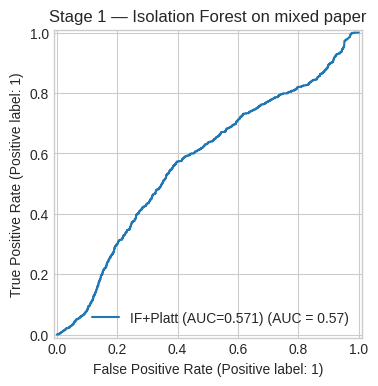

Fault classifier Macro-F1=0.8015  Acc=0.9245  rareR=0.6130  family=wm  β=1.0


,Class,P,R,F1,Support
0,healthy,0.96,0.95,0.96,3992
1,congestion_breach,0.94,0.98,0.96,252
2,tunnel_degradation,0.83,0.95,0.88,170
3,bgp_route_flap,0.57,0.60,0.58,245
4,vrf_leakage,0.63,0.63,0.63,123


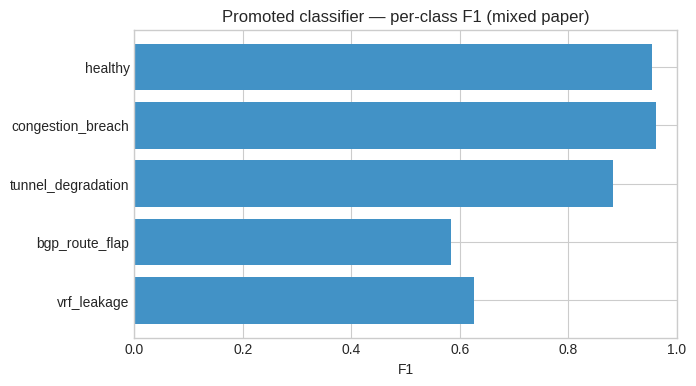

In [4]:
# Optional companion rebuild (does not touch fault classifier)
if REBUILD_MODELS:
    import subprocess
    print("REBUILD_MODELS=True → running scripts/deca_retrain_companions.py …")
    subprocess.run([sys.executable, str(REPO_ROOT / "scripts" / "deca_retrain_companions.py")], check=True)

y_raw = df["unified_label"].astype(str)
le_classes = [c for c in UNIFIED_LABELS if c in set(y_raw)]
le_classes += sorted(set(y_raw) - set(le_classes))
class_to_idx = {c: i for i, c in enumerate(le_classes)}
y = y_raw.map(class_to_idx).astype(int).values
rng = np.random.default_rng(EXAM_SEED)
blind = stratified_blind_holdout(y, df, 0.20, rng=rng, policy="random")
X_ex = df.iloc[blind][feats]
y_ex = y[blind]
y_anom = df.iloc[blind]["is_anomaly"].astype(int).values
exam_counts = {le_classes[i]: int(np.sum(y_ex == i)) for i in range(len(le_classes))}
print("Exam seed", EXAM_SEED, "mix:", exam_counts)
print(f"exam_rows={int(blind.sum()):,} / {len(df):,}")

results = {}

# --- Isolation Forest ---
if_dir = MODELS_DIR / "isolation_forest"
if_pipe = joblib.load(if_dir / "isolation_forest.pkl")
cal = joblib.load(if_dir / "confidence_calibrator.pkl")
meta = joblib.load(if_dir / "feature_scaler.pkl")
cols = meta.get("feature_columns") or list(X_ex.columns)
raw = -if_pipe.decision_function(X_ex[cols])
p = cal.predict_proba(raw.reshape(-1, 1))[:, 1]
if_auc = float(roc_auc_score(y_anom, p)) if len(np.unique(y_anom)) > 1 else float("nan")
results["isolation_forest"] = {"roc_auc": if_auc}
print(f"IF+Platt ROC-AUC={if_auc:.4f}")
fig, ax = plt.subplots(figsize=(5, 4))
RocCurveDisplay.from_predictions(y_anom, p, ax=ax, name=f"IF+Platt (AUC={if_auc:.3f})")
ax.set_title("Stage 1 — Isolation Forest on mixed paper")
plt.show()

# --- Promoted fault classifier ---
bundle = joblib.load(MODELS_DIR / "fault_classifier" / "fault_classifier_xgb.pkl")
le = joblib.load(MODELS_DIR / "fault_classifier" / "label_encoder.pkl")
classes = list(le.get("classes") or le_classes)
pred = predict_weighted_multiclass(
    bundle["gate"], bundle["full_clf"], X_ex,
    healthy_idx=int(bundle["healthy_idx"]),
    gate_thr=float(bundle["gate_thr"]),
    class_thr={int(k): float(v) for k, v in bundle.get("class_thr", {}).items()},
)
report = classification_report(
    y_ex, pred, labels=list(range(len(classes))), target_names=classes,
    zero_division=0, output_dict=True,
)
rare_ids = [class_to_idx[c] for c in RARE if c in class_to_idx]
rare_r = float(np.mean([recall_score(y_ex == c, pred == c, zero_division=0) for c in rare_ids]))
macro = float(f1_score(y_ex, pred, average="macro", zero_division=0))
acc = float(accuracy_score(y_ex, pred))
results["fault_classifier"] = {
    "macro_f1": macro, "accuracy": acc, "mean_rare_recall": rare_r,
    "head_family": bundle.get("head_family") or bundle.get("phase"),
    "rare_boost": bundle.get("rare_boost"),
    "per_class": {c: report[c] for c in classes if c in report},
}
print(
    f"Fault classifier Macro-F1={macro:.4f}  Acc={acc:.4f}  rareR={rare_r:.4f}  "
    f"family={results['fault_classifier']['head_family']}  β={bundle.get('rare_boost')}"
)
pc = pd.DataFrame([
    {"Class": c, "P": report[c]["precision"], "R": report[c]["recall"],
     "F1": report[c]["f1-score"], "Support": int(report[c]["support"])}
    for c in classes if c in report
])
display(pc.style.format({"P": "{:.2f}", "R": "{:.2f}", "F1": "{:.2f}"}))

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(pc["Class"][::-1], pc["F1"][::-1], color="#4292c6")
ax.set_xlim(0, 1); ax.set_xlabel("F1"); ax.set_title("Promoted classifier — per-class F1 (mixed paper)")
plt.show()


I0000 00:00:1784132235.735974  133322 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1784132235.779536  133322 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784132237.063735  133322 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
E0000 00:00:1784132237.220384  133322 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


LSTM MAE=2.467 min  n=1938


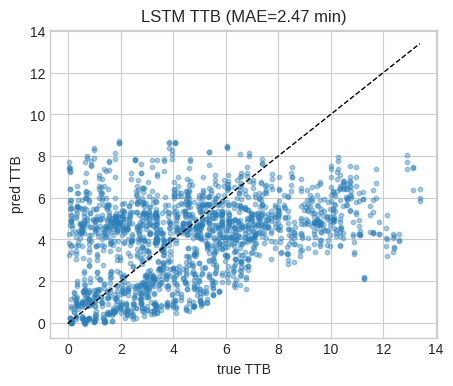

/home/brain/deca-isro/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
21:47:18 - cmdstanpy - INFO - Chain [1] start processing
21:47:20 - cmdstanpy - INFO - Chain [1] done processing


Prophet ifInOctets: MAE=1.816e+09  hold=1068


21:47:21 - cmdstanpy - INFO - Chain [1] start processing
21:47:21 - cmdstanpy - INFO - Chain [1] done processing
21:47:21 - cmdstanpy - INFO - Chain [1] start processing
21:47:21 - cmdstanpy - INFO - Chain [1] done processing


Prophet jitter_ms: MAE=185.8  hold=1600
Prophet bgp_update_rate: MAE=8882  hold=64


,metric,mae,n_hold
0,ifInOctets,1.815527e+09,1068
1,jitter_ms,1.858157e+02,1600
2,bgp_update_rate,8.882195e+03,64


In [5]:
# --- LSTM ---
try:
    from tensorflow import keras
    scaler = joblib.load(MODELS_DIR / "lstm" / "lstm_scaler.pkl")
    model = keras.models.load_model(MODELS_DIR / "lstm" / "fault_lstm_v1.keras")
    cols = list(scaler["feature_columns"])
    seq_len = int(scaler["seq_len"])
    mean, std = np.asarray(scaler["mean"]), np.asarray(scaler["std"])
    std = np.where(std < 1e-9, 1.0, std)
    net = df[df["source"] == "network"].sort_index()
    mat = net[cols].apply(pd.to_numeric, errors="coerce")
    mat = mat.fillna(mat.median(numeric_only=True)).fillna(0.0).values.astype(np.float64)
    ttb = pd.to_numeric(net["time_to_breach_minutes"], errors="coerce").values
    idx = net.index
    blind_set = set(pd.DatetimeIndex(df.index[blind]))
    Xs, ys = [], []
    for i in range(seq_len - 1, len(mat)):
        if np.isnan(ttb[i]) or idx[i] not in blind_set:
            continue
        Xs.append(mat[i - seq_len + 1 : i + 1])
        ys.append(float(ttb[i]))
    if Xs:
        X = (np.asarray(Xs) - mean) / std
        yt = np.asarray(ys)
        pred = model.predict(X, verbose=0).ravel()
        mae = float(mean_absolute_error(yt, pred))
        results["lstm"] = {"mae_minutes": mae, "n": len(yt)}
        print(f"LSTM MAE={mae:.3f} min  n={len(yt)}")
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.scatter(yt, pred, s=10, alpha=0.4, c="#2c7fb8")
        lim = [min(yt.min(), pred.min()), max(yt.max(), pred.max())]
        ax.plot(lim, lim, "k--", lw=1)
        ax.set_xlabel("true TTB"); ax.set_ylabel("pred TTB")
        ax.set_title(f"LSTM TTB (MAE={mae:.2f} min)")
        plt.show()
    else:
        results["lstm"] = {"mae_minutes": None, "n": 0}
        print("LSTM: no sequences ending on exam rows")
except Exception as e:
    results["lstm"] = {"error": str(e)}
    print("LSTM skip:", e)

# --- Prophet (honest prefix refit on raw series tails) ---
try:
    from prophet import Prophet
    raw = pd.read_parquet(PROCESSED_DIR / "deca_unified_raw.parquet")
    prophet_rows = []
    for metric, folder in [
        ("ifInOctets", "prophet_ifInOctets"),
        ("jitter_ms", "prophet_jitter_ms"),
        ("bgp_update_rate", "prophet_bgp_update_rate"),
    ]:
        s = raw.loc[raw["metric"] == metric, ["timestamp", "value"]].copy()
        s["timestamp"] = pd.to_datetime(s["timestamp"], utc=True)
        s["value"] = pd.to_numeric(s["value"], errors="coerce")
        s = s.dropna().sort_values("timestamp")
        s["ds"] = s["timestamp"].dt.tz_localize(None)
        s["y"] = s["value"]
        series = s[["ds", "y"]].drop_duplicates("ds")
        if len(series) > 8000:
            pick = np.linspace(0, len(series) - 1, 8000).astype(int)
            series = series.iloc[pick].reset_index(drop=True)
        n_hold = max(5, min(len(series) // 5, int(round(len(series) * 0.2))))
        train, hold = series.iloc[:-n_hold], series.iloc[-n_hold:]
        m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False,
                    changepoint_prior_scale=0.05)
        m.fit(train)
        fc = m.predict(hold[["ds"]])
        mae = float(mean_absolute_error(hold["y"].values, fc["yhat"].values))
        prophet_rows.append({"metric": metric, "mae": mae, "n_hold": len(hold)})
        print(f"Prophet {metric}: MAE={mae:.4g}  hold={len(hold)}")
    results["prophet"] = prophet_rows
    display(pd.DataFrame(prophet_rows))
except Exception as e:
    results["prophet"] = {"error": str(e)}
    print("Prophet skip:", e)


## Stage 5 — CE–PE–CE topology


eccentricity: {'PE1': 1, 'PE2': 1, 'CORE': 1}


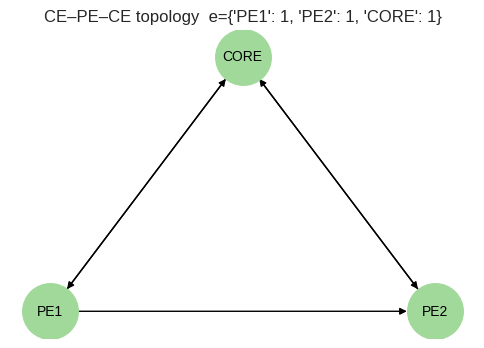

In [6]:
topo_path = MODELS_DIR / "topology" / "topology_graph.json"
if topo_path.exists():
    payload = json.loads(topo_path.read_text())
    ecc = payload.get("eccentricity")
else:
    g = nx.DiGraph()
    nodes = {"PE1": {}, "PE2": {}, "CORE": {}}
    for n in nodes: g.add_node(n)
    g.add_edges_from([("PE1","CORE"),("CORE","PE1"),("PE2","CORE"),("CORE","PE2"),("PE1","PE2")])
    und = g.to_undirected()
    ecc = {n: nx.eccentricity(und, n) for n in und.nodes}
    payload = {"eccentricity": ecc}
results["topology"] = {"eccentricity": ecc}
print("eccentricity:", ecc)
fig, ax = plt.subplots(figsize=(6, 4))
pos = {"PE1": (-1, 0), "CORE": (0, 0.6), "PE2": (1, 0)}
G = nx.DiGraph()
G.add_nodes_from(["PE1","CORE","PE2"])
G.add_edges_from([("PE1","CORE"),("CORE","PE1"),("PE2","CORE"),("CORE","PE2"),("PE1","PE2")])
nx.draw_networkx(G, pos=pos, ax=ax, node_color="#a1d99b", node_size=1600, font_size=10, arrows=True)
ax.set_title(f"CE–PE–CE topology  e={ecc}"); ax.axis("off")
plt.show()


## Stage 6 — Classroom + scoreboard snapshot

Pulls the School Exam promote / 5‑seed classroom report and builds the cumulative scoreboard from **this** notebook’s mixed paper.


### School Exam promote (classroom)

,head_family,exam_macro_f1,exam_mean_rare_recall,rare_boost,baseline_floor,promoted
0,wm,0.724525,0.452149,1.0,0.71,True


### 5-seed classroom stability (`seed_report.md`)

# DECA repeated-holdout validation — rare-class stability

- **When:** `2026-07-15T15:55:29.253556+00:00`
- **Seeds:** 5 fresh stratified papers `[633343961, 819453604, 672697179, 1311823148, 354500530]`
- **Families:** ['plain', 'wm'] · β=[1.0, 1.5]
- **Challenger (wm/moe) beat plain on:** 4/5 papers
- **Gate PASS:** 5/5 papers

Technique: **repeated holdout validation** with an automated **promotion gate** (demo name: "School Exam"). Ranges below are mean ± std [min, max] across seeds.

## Honest champion config (`plain`, retrained per paper)

| Metric | Range across seeds |
| --- | --- |
| Macro-F1 | 0.729 ± 0.003  [0.726, 0.733] |
| Mean rare recall | 0.612 ± 0.084  [0.495, 0.690] |
| vrf_leakage F1 | 0.467 ± 0.025  [0.447, 0.517] |
| bgp_route_flap F1 | 0.477 ± 0.018  [0.450, 0.499] |

## Best family per paper (challenger allowed)

| Metric | Range across seeds |
| --- | --- |
| Macro-F1 | 0.732 ± 0.004  [0.727, 0.736] |
| Mean rare recall | 0.638 ± 0.072  [0.495, 0.684] |
| vrf_leakage F1 | 0.466 ± 0.021  [0.447, 0.506] |
| bgp_route_flap F1 | 0.481 ± 0.015  [0.467, 0.501] |

## Per-seed detail

| Seed | Champion Macro | Best family | Best Macro | Gate |
| --- | ---: | --- | ---: | --- |
| 633343961 | 0.726 | wm | 0.727 | PASS |
| 819453604 | 0.728 | wm | 0.736 | PASS |
| 672697179 | 0.733 | wm | 0.734 | PASS |
| 1311823148 | 0.732 | wm | 0.734 | PASS |
| 354500530 | 0.727 | plain | 0.727 | PASS |

> Reading: a wide std or low min on a rare class means that class's F1 is **seed-sensitive (noise)**; a tight band means the number is **real**. Promote only when the challenger wins consistently, not on one lucky paper.


### Cumulative model scoreboard (this notebook run)

,Component,Primary score,Notes
0,Isolation Forest + Platt,ROC-AUC 0.571,Live artifact on mixed paper
1,Fault classifier (promoted),"Macro-F1 0.802, Acc 0.92",family=wm β=1.0; rareR=0.6130081300813008
2,LSTM time-to-breach,MAE 2.467 min,n=1938 sequences on paper
3,Prophet ×3,honest-refit holdout,ifInOctets=1.816e+09 / jitter_ms=185.8 / bgp_u...
4,Topology,"e(v)={'PE1': 1, 'PE2': 1, 'CORE': 1}",PE1–PE2–CORE


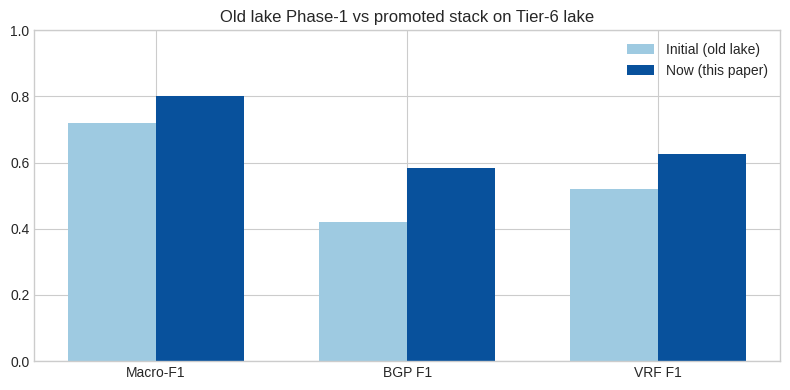

Wrote /home/brain/deca-isro/models/notebook_results_latest.json
Wrote /home/brain/deca-isro/models/scoreboard_summary.csv


Full narrative: [`docs/DECA_TEST_SCORES.md`](../docs/DECA_TEST_SCORES.md)

In [7]:
# School Exam / classroom artifacts
se_dir = MODELS_DIR / "school_exam"
latest = json.loads((se_dir / "latest_exam.json").read_text()) if (se_dir / "latest_exam.json").exists() else {}
seed_md = (se_dir / "seed_report.md").read_text() if (se_dir / "seed_report.md").exists() else "_missing seed_report.md_"
man = json.loads((MODELS_DIR / "manifest.json").read_text()) if (MODELS_DIR / "manifest.json").exists() else {}

display(Markdown("### School Exam promote (classroom)"))
se = man.get("school_exam") or latest.get("best") or {}
promote_tbl = pd.DataFrame([{
    "head_family": se.get("head_family") or latest.get("best", {}).get("family"),
    "exam_macro_f1": se.get("exam_macro_f1") or latest.get("best", {}).get("exam_macro_f1"),
    "exam_mean_rare_recall": se.get("exam_mean_rare_recall") or latest.get("best", {}).get("exam_mean_rare_recall"),
    "rare_boost": se.get("rare_boost") or latest.get("best", {}).get("rare_boost"),
    "baseline_floor": se.get("baseline_macro_f1") or latest.get("baseline_macro_f1"),
    "promoted": se.get("promoted", latest.get("gate_ok")),
}])
display(promote_tbl)

display(Markdown("### 5-seed classroom stability (`seed_report.md`)"))
display(Markdown(seed_md))

# Cumulative scoreboard from this run
fc = results.get("fault_classifier", {})
scoreboard_rows = [
    {"Component": "Isolation Forest + Platt",
     "Primary score": f"ROC-AUC {results.get('isolation_forest', {}).get('roc_auc', float('nan')):.3f}",
     "Notes": "Live artifact on mixed paper"},
    {"Component": "Fault classifier (promoted)",
     "Primary score": f"Macro-F1 {fc.get('macro_f1', float('nan')):.3f}, Acc {fc.get('accuracy', float('nan')):.2f}",
     "Notes": f"family={fc.get('head_family')} β={fc.get('rare_boost')}; rareR={fc.get('mean_rare_recall')}"},
]
if results.get("lstm", {}).get("mae_minutes") is not None:
    scoreboard_rows.append({
        "Component": "LSTM time-to-breach",
        "Primary score": f"MAE {results['lstm']['mae_minutes']:.3f} min",
        "Notes": f"n={results['lstm'].get('n')} sequences on paper",
    })
if isinstance(results.get("prophet"), list):
    scoreboard_rows.append({
        "Component": "Prophet ×3",
        "Primary score": "honest-refit holdout",
        "Notes": " / ".join(f"{r['metric']}={r['mae']:.4g}" for r in results["prophet"]),
    })
scoreboard_rows.append({
    "Component": "Topology",
    "Primary score": f"e(v)={results.get('topology', {}).get('eccentricity')}",
    "Notes": "PE1–PE2–CORE",
})
scoreboard_df = pd.DataFrame(scoreboard_rows)
display(Markdown("### Cumulative model scoreboard (this notebook run)"))
display(scoreboard_df)

# Quick before→after chart (documented numbers)
fig, ax = plt.subplots(figsize=(8, 4))
metrics = ["Macro-F1", "BGP F1", "VRF F1"]
old = [0.721, 0.42, 0.52]
new = [fc.get("macro_f1", 0.802),
       fc.get("per_class", {}).get("bgp_route_flap", {}).get("f1-score", 0.58),
       fc.get("per_class", {}).get("vrf_leakage", {}).get("f1-score", 0.63)]
x = np.arange(len(metrics)); w = 0.35
ax.bar(x - w/2, old, w, label="Initial (old lake)", color="#9ecae1")
ax.bar(x + w/2, new, w, label="Now (this paper)", color="#08519c")
ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylim(0, 1)
ax.set_title("Old lake Phase-1 vs promoted stack on Tier-6 lake")
ax.legend(); fig.tight_layout(); plt.show()

# Persist notebook run snapshot (does not overwrite models/)
out = MODELS_DIR / "notebook_results_latest.json"
payload = {
    "notebook_date": datetime.now(timezone.utc).isoformat(),
    "exam_seed": EXAM_SEED,
    "n_lake_rows": int(len(df)),
    "exam_label_counts": exam_counts,
    "results": results,
    "school_exam": se if isinstance(se, dict) else {},
}
out.write_text(json.dumps(payload, indent=2, default=str))
scoreboard_df.to_csv(MODELS_DIR / "scoreboard_summary.csv", index=False)
print(f"Wrote {out}")
print(f"Wrote {MODELS_DIR / 'scoreboard_summary.csv'}")
display(Markdown("Full narrative: [`docs/DECA_TEST_SCORES.md`](../docs/DECA_TEST_SCORES.md)"))
